In [5]:
# Install Libraries
!pip install xgboost prophet --quiet
print("Done installing!")

Done installing!


In [6]:
#  Import All Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.cluster import KMeans, DBSCAN

# XGBoost
from xgboost import XGBRegressor, XGBClassifier

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [7]:
#  Load Dataset
# Upload household_power_consumption.txt first using the Files panel (left sidebar)
# OR uncomment the two lines below to upload via dialog:

# from google.colab import files
# files.upload()

FILE_PATH = 'household_power_consumption.txt'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?'],
    low_memory=False
)

print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Raw shape: (1189153, 8)
Columns: ['Datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Date range: 2006-12-16 17:24:00 → 2009-03-21 12:36:00


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
#  Data Cleaning
print(f"Missing values before cleaning:\n{df.isnull().sum()}")

df.dropna(inplace=True)
df.set_index('Datetime', inplace=True)

# Ensure numeric types
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
df[numeric_cols] = df[numeric_cols].astype(float)

print(f"\nShape after cleaning: {df.shape}")
print(f"Missing values after: {df.isnull().sum().sum()}")
df.describe()

Missing values before cleaning:
Datetime                    0
Global_active_power      4137
Global_reactive_power    4137
Voltage                  4137
Global_intensity         4137
Sub_metering_1           4137
Sub_metering_2           4138
Sub_metering_3           4138
dtype: int64

Shape after cleaning: (1185015, 7)
Missing values after: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.185015e+06,1.185015e+06,1.185015e+06,1.185015e+06,1.185015e+06,1.185015e+06,1.185015e+06
mean,1.129826e+00,1.156337e-01,2.403153e+02,4.796480e+00,1.197280e+00,1.452276e+00,6.088587e+00
std,1.129840e+00,1.082906e-01,3.416113e+00,4.758667e+00,6.386874e+00,6.361160e+00,8.289541e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.960000e-01,0.000000e+00,2.382400e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.940000e-01,9.400000e-02,2.404800e+02,2.600000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.568000e+00,1.800000e-01,2.425400e+02,6.600000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.539400e+02,4.840000e+01,8.200000e+01,7.800000e+01,3.100000e+01


In [9]:
#  Feature Engineering
# Resample to daily level (minute-level data → daily averages)
daily = df.resample('D').agg({
    'Global_active_power':   'mean',
    'Global_reactive_power': 'mean',
    'Voltage':               'mean',
    'Global_intensity':      'mean',
    'Sub_metering_1':        'sum',
    'Sub_metering_2':        'sum',
    'Sub_metering_3':        'sum'
}).dropna()

# Time features
daily['DayOfWeek'] = daily.index.dayofweek
daily['Month']     = daily.index.month
daily['IsWeekend'] = (daily['DayOfWeek'] >= 5).astype(int)
daily['Quarter']   = daily.index.quarter

# Energy bill simulation (₹6.5 per kWh — change to your local tariff)
TARIFF = 6.5
daily['Daily_kWh'] = daily['Global_active_power'] * 24
daily['Bill_INR']  = daily['Daily_kWh'] * TARIFF

# Binary classification target: 1 = high usage day (above median)
median_power       = daily['Global_active_power'].median()
daily['HighUsage'] = (daily['Global_active_power'] > median_power).astype(int)

print(f"Daily dataset shape: {daily.shape}")
print(f"Median active power: {median_power:.4f} kW")
print(f"High usage days: {daily['HighUsage'].sum()} / {len(daily)}")
daily.head()

Daily dataset shape: (826, 14)
Median active power: 1.1183 kW
High usage days: 413 / 826


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DayOfWeek,Month,IsWeekend,Quarter,Daily_kWh,Bill_INR,HighUsage
Datetime,,,,,,,,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.0,546.0,4926.0,5,12,1,4,73.283394,476.342061,1
2006-12-17,2.354486,0.156949,240.087028,9.999028,2033.0,4187.0,13341.0,6,12,1,4,56.507667,367.299833,1
2006-12-18,1.530435,0.112356,241.231694,6.421667,1063.0,2621.0,14018.0,0,12,0,4,36.730433,238.747817,1
2006-12-19,1.157079,0.104821,241.999313,4.926389,839.0,7602.0,6197.0,1,12,0,4,27.769900,180.504350,1
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.0,2648.0,14063.0,2,12,0,4,37.095800,241.122700,1


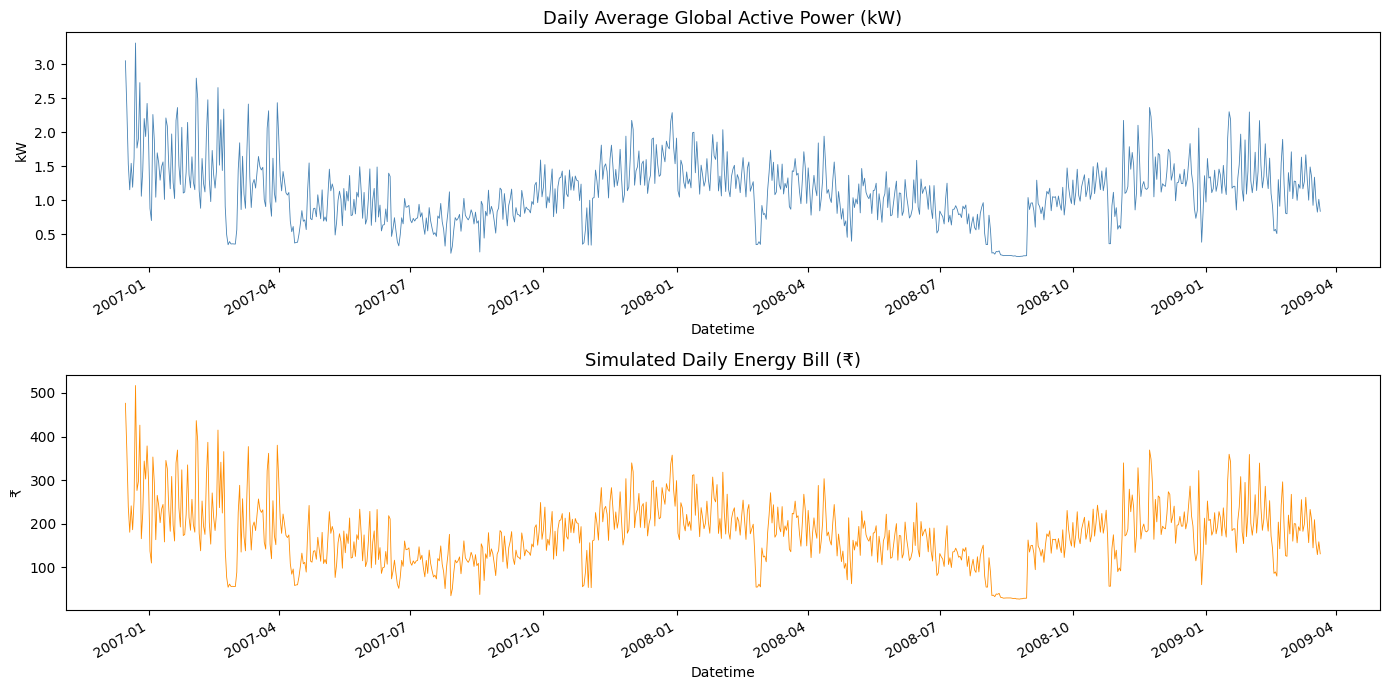

In [10]:
#  EDA: Time Series Plots
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

daily['Global_active_power'].plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Daily Average Global Active Power (kW)', fontsize=13)
axes[0].set_ylabel('kW')

daily['Bill_INR'].plot(ax=axes[1], color='darkorange', linewidth=0.6)
axes[1].set_title('Simulated Daily Energy Bill (₹)', fontsize=13)
axes[1].set_ylabel('₹')

plt.tight_layout()
plt.show()

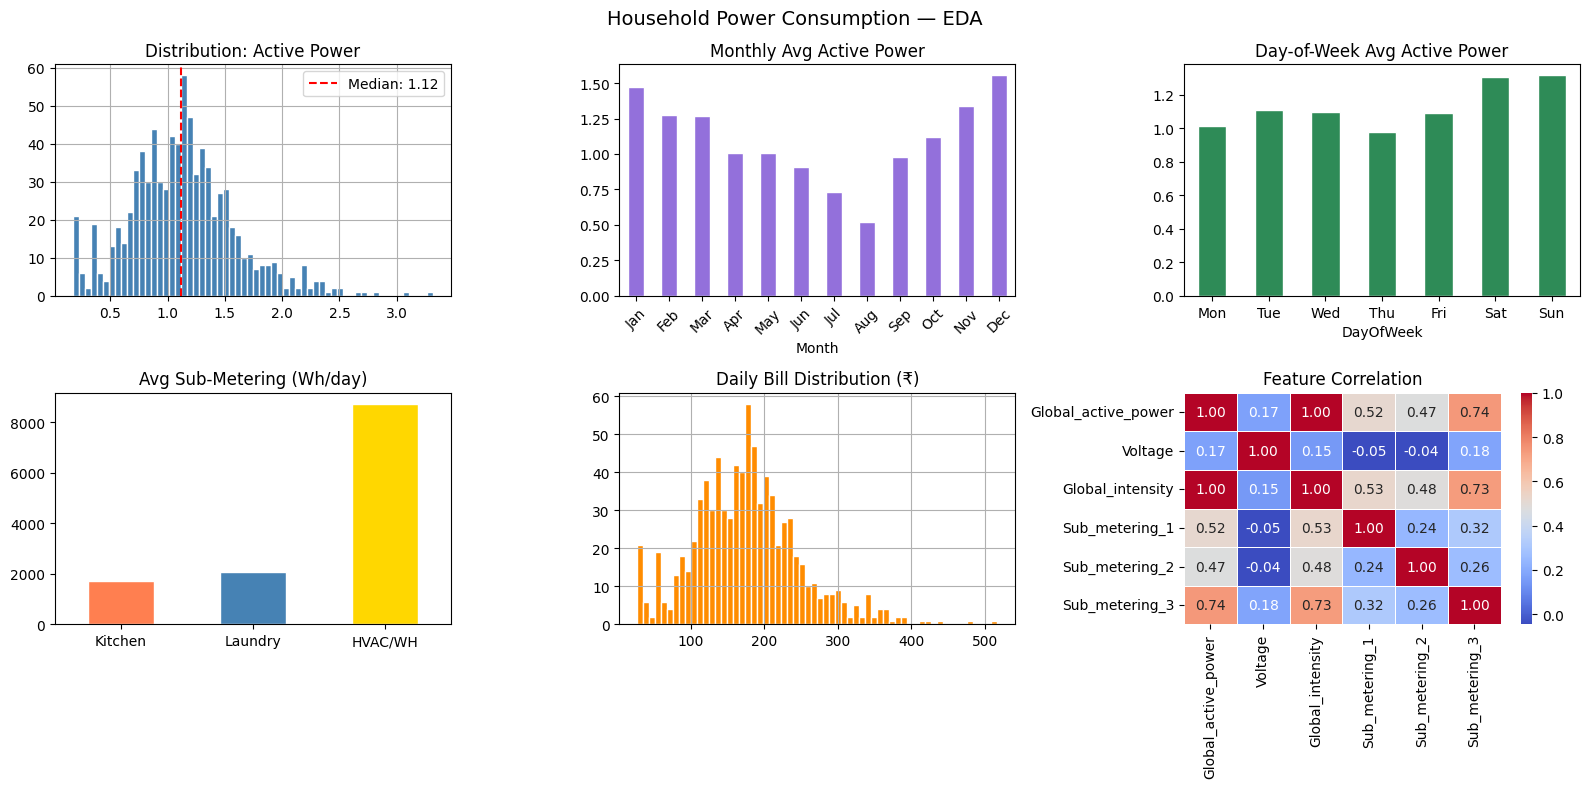

In [11]:
#  EDA: Distributions and Patterns
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Household Power Consumption — EDA', fontsize=14)

# Distribution
daily['Global_active_power'].hist(ax=axes[0,0], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution: Active Power')
axes[0,0].axvline(median_power, color='red', linestyle='--', label=f'Median: {median_power:.2f}')
axes[0,0].legend()

# Monthly avg
daily.groupby('Month')['Global_active_power'].mean().plot(
    kind='bar', ax=axes[0,1], color='mediumpurple', edgecolor='white')
axes[0,1].set_title('Monthly Avg Active Power')
axes[0,1].set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# Weekly pattern
daily.groupby('DayOfWeek')['Global_active_power'].mean().plot(
    kind='bar', ax=axes[0,2], color='seagreen', edgecolor='white')
axes[0,2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
axes[0,2].set_title('Day-of-Week Avg Active Power')

# Sub metering breakdown
sub_means = daily[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].mean()
sub_means.plot(kind='bar', ax=axes[1,0], color=['coral','steelblue','gold'], edgecolor='white')
axes[1,0].set_title('Avg Sub-Metering (Wh/day)')
axes[1,0].set_xticklabels(['Kitchen','Laundry','HVAC/WH'], rotation=0)

# Bill distribution
daily['Bill_INR'].hist(ax=axes[1,1], bins=60, color='darkorange', edgecolor='white')
axes[1,1].set_title('Daily Bill Distribution (₹)')

# Correlation heatmap
corr_cols = ['Global_active_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
sns.heatmap(daily[corr_cols].corr(), ax=axes[1,2], annot=True,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

In [12]:
#  Train/Test Split and Scaling
FEATURES = [
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Month', 'DayOfWeek', 'IsWeekend', 'Quarter'
]

X       = daily[FEATURES]
y_reg   = daily['Global_active_power']   # regression target
y_clf   = daily['HighUsage']             # classification target

# Regression split (no stratify needed)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Classification split (stratified to keep class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Scalers (needed for SVR, SVM, KNN, MLP, Logistic)
scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)

print(f"Regression  — Train: {X_train_r.shape}  |  Test: {X_test_r.shape}")
print(f"Classification — Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"\nClass balance in full dataset:\n{y_clf.value_counts()}")

Regression  — Train: (660, 9)  |  Test: (166, 9)
Classification — Train: (660, 9)  |  Test: (166, 9)

Class balance in full dataset:
HighUsage
1    413
0    413
Name: count, dtype: int64


In [13]:
#  Helper Functions (run this before any model cell)
reg_results = []
clf_results = []

def eval_regression(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    reg_results.append({'Model': name, 'RMSE': round(rmse,4),
                        'MAE': round(mae,4), 'R²': round(r2,4)})
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*50}")
    return model, preds

def eval_classification(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    try:
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
    except AttributeError:
        auc = roc_auc_score(y_te, model.decision_function(X_te))
    clf_results.append({'Model': name, 'Accuracy': round(acc,4), 'AUC-ROC': round(auc,4)})
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_te, preds, target_names=['Low Usage','High Usage']))
    return model, preds

def plot_confusion(name, y_true, y_pred):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low','High'])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

def plot_actual_vs_pred(name, y_true, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, alpha=0.3, s=8, color='steelblue')
    mn, mx = y_true.min(), y_true.max()
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    plt.xlabel('Actual'); plt.ylabel('Predicted')
    plt.title(f'{name} — Actual vs Predicted')
    plt.legend(); plt.tight_layout(); plt.show()

print("Helper functions ready ✅  — reg_results and clf_results are reset.")

Helper functions ready ✅  — reg_results and clf_results are reset.


  Linear Regression
  RMSE : 0.0118
  MAE  : 0.0088
  R²   : 0.9995


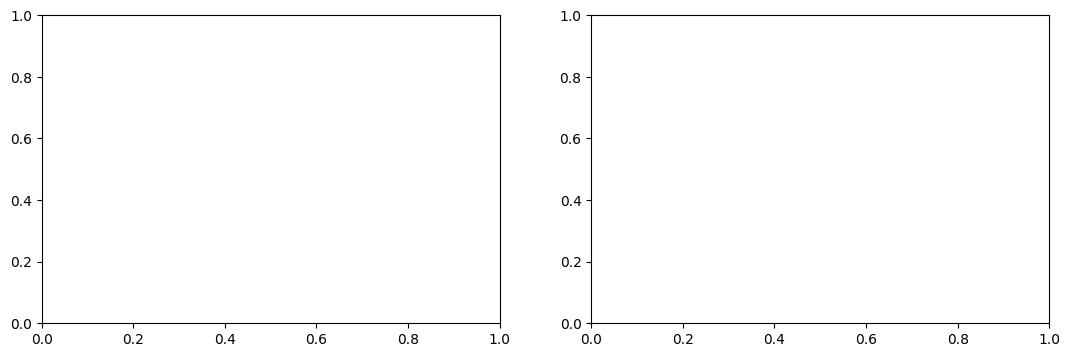

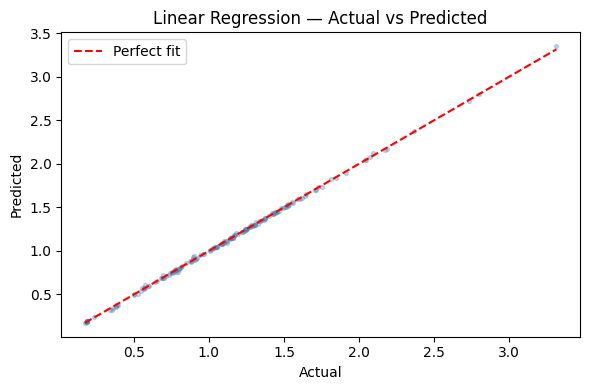

<Figure size 640x480 with 0 Axes>

In [14]:
# MODEL 1: Linear Regression
lr_model, lr_preds = eval_regression(
    'Linear Regression', LinearRegression(),
    X_train_r, y_train_r, X_test_r, y_test_r
)

# Feature coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_actual_vs_pred('Linear Regression', y_test_r, lr_preds)

coef_df.plot(kind='barh', x='Feature', y='Coefficient',
             ax=axes[1], legend=False, color='steelblue')
axes[1].set_title('Feature Coefficients')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

Best alpha: 0.1
  Ridge Regression
  RMSE : 0.0118
  MAE  : 0.0088
  R²   : 0.9995


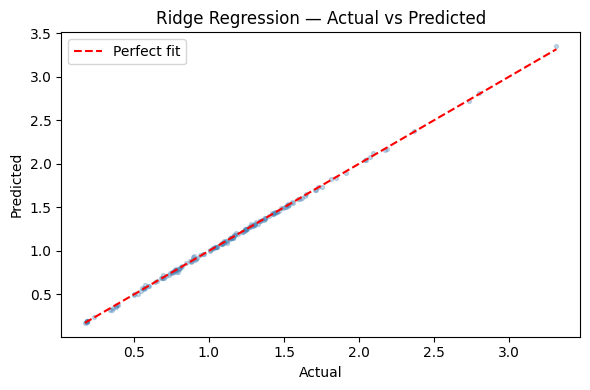

In [15]:
#  MODEL 2: Ridge Regression (L2 regularisation)
ridge_gs = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5, scoring='r2', n_jobs=-1
)
ridge_gs.fit(X_train_rs, y_train_r)
print(f"Best alpha: {ridge_gs.best_params_['alpha']}")

ridge_model, ridge_preds = eval_regression(
    'Ridge Regression', ridge_gs.best_estimator_,
    X_train_rs, y_train_r, X_test_rs, y_test_r
)
plot_actual_vs_pred('Ridge Regression', y_test_r, ridge_preds)

Best alpha: 0.0001
  Lasso Regression
  RMSE : 0.0117
  MAE  : 0.0088
  R²   : 0.9995

Lasso Coefficients (0 = feature eliminated by Lasso):
Sub_metering_1     -0.003894
Sub_metering_2     -0.002075
IsWeekend          -0.000671
Month              -0.000000
DayOfWeek           0.000000
Quarter             0.000000
Sub_metering_3      0.003237
Voltage             0.010532
Global_intensity    0.452321


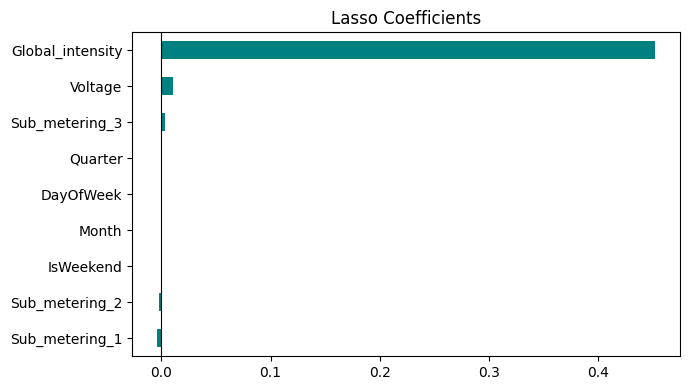

In [16]:
#  MODEL 3: Lasso Regression (L1 — automatic feature selection)
lasso_gs = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]},
    cv=5, scoring='r2', n_jobs=-1
)
lasso_gs.fit(X_train_rs, y_train_r)
print(f"Best alpha: {lasso_gs.best_params_['alpha']}")

lasso_model, lasso_preds = eval_regression(
    'Lasso Regression', lasso_gs.best_estimator_,
    X_train_rs, y_train_r, X_test_rs, y_test_r
)

# Show which features Lasso killed (coeff = 0 means eliminated)
lasso_coef = pd.Series(lasso_model.coef_, index=FEATURES).sort_values()
print("\nLasso Coefficients (0 = feature eliminated by Lasso):")
print(lasso_coef.to_string())

lasso_coef.plot(kind='barh', figsize=(7,4), title='Lasso Coefficients', color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

  Polynomial Regression (deg 2)
  RMSE : 0.0104
  MAE  : 0.0077
  R²   : 0.9996


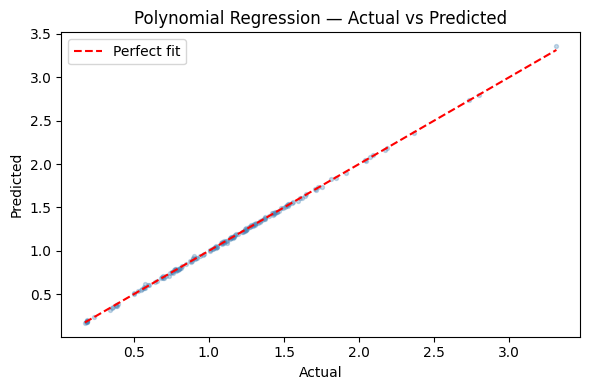


Original features: 9
After degree-2 expansion: 54


In [17]:
#  MODEL 4: Polynomial Regression (degree 2)
poly_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])

poly_model, poly_preds = eval_regression(
    'Polynomial Regression (deg 2)', poly_pipeline,
    X_train_r, y_train_r, X_test_r, y_test_r
)
plot_actual_vs_pred('Polynomial Regression', y_test_r, poly_preds)

print(f"\nOriginal features: {len(FEATURES)}")
print(f"After degree-2 expansion: {poly_pipeline.named_steps['poly'].n_output_features_}")

  Decision Tree Regressor
  RMSE : 0.0411
  MAE  : 0.0164
  R²   : 0.9937
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


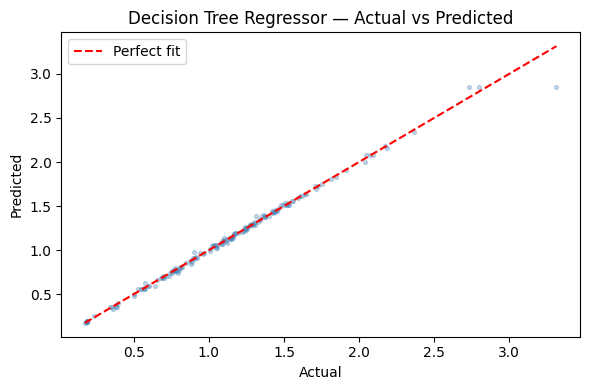

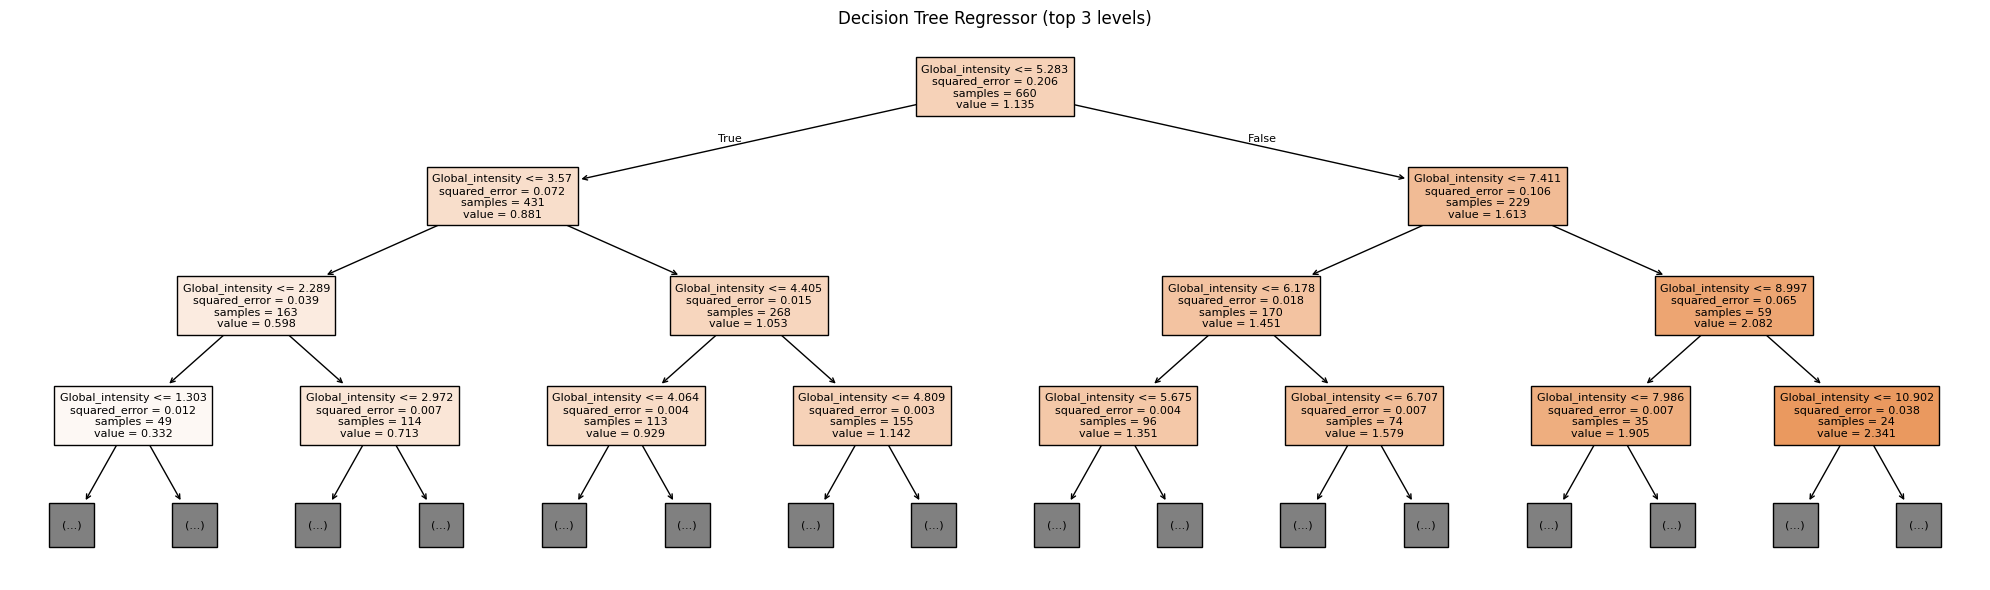

In [18]:
# MODEL 5: Decision Tree Regressor
dt_reg_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        'max_depth':        [3, 5, 7, 10, None],
        'min_samples_split':[2, 5, 10],
        'min_samples_leaf': [1, 2, 5]
    },
    cv=5, scoring='r2', n_jobs=-1
)
dt_reg_model, dt_reg_preds = eval_regression(
    'Decision Tree Regressor', dt_reg_gs,
    X_train_r, y_train_r, X_test_r, y_test_r
)
print(f"Best params: {dt_reg_gs.best_params_}")
plot_actual_vs_pred('Decision Tree Regressor', y_test_r, dt_reg_preds)

# Visualise the tree (top 3 levels only)
plt.figure(figsize=(20, 6))
plot_tree(dt_reg_gs.best_estimator_, max_depth=3,
          feature_names=FEATURES, filled=True, fontsize=8)
plt.title('Decision Tree Regressor (top 3 levels)')
plt.tight_layout(); plt.show()

  Random Forest Regressor
  RMSE : 0.0550
  MAE  : 0.0170
  R²   : 0.9888


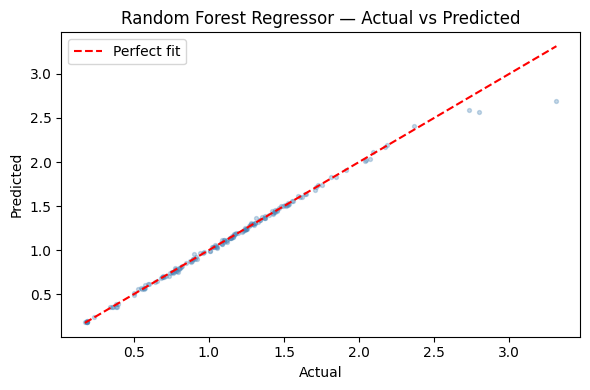

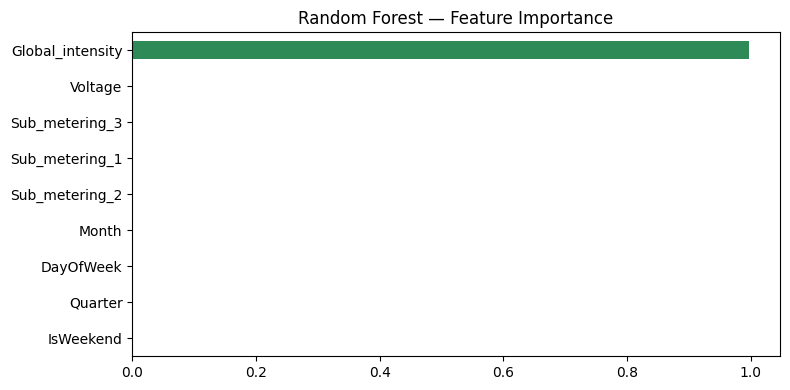

In [19]:
#  MODEL 6: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                                random_state=42, n_jobs=-1)
rf_reg_model, rf_reg_preds = eval_regression(
    'Random Forest Regressor', rf_reg,
    X_train_r, y_train_r, X_test_r, y_test_r
)
plot_actual_vs_pred('Random Forest Regressor', y_test_r, rf_reg_preds)

# Feature importance
fi = pd.Series(rf_reg_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), color='seagreen',
        title='Random Forest — Feature Importance')
plt.tight_layout(); plt.show()

  Gradient Boosting Regressor
  RMSE : 0.0406
  MAE  : 0.0119
  R²   : 0.9939


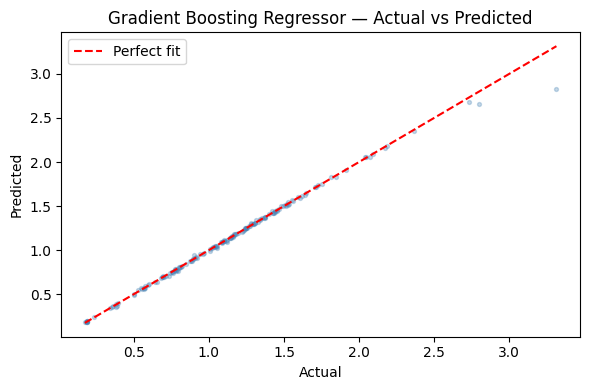

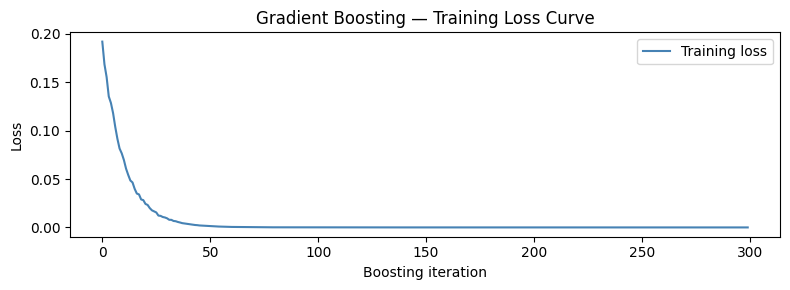

In [20]:
#  MODEL 7: Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    random_state=42
)
gb_reg_model, gb_reg_preds = eval_regression(
    'Gradient Boosting Regressor', gb_reg,
    X_train_r, y_train_r, X_test_r, y_test_r
)
plot_actual_vs_pred('Gradient Boosting Regressor', y_test_r, gb_reg_preds)

# Training deviance (loss) curve
plt.figure(figsize=(8, 3))
plt.plot(gb_reg_model.train_score_, color='steelblue', label='Training loss')
plt.xlabel('Boosting iteration'); plt.ylabel('Loss')
plt.title('Gradient Boosting — Training Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()

  XGBoost Regressor
  RMSE : 0.0774
  MAE  : 0.0219
  R²   : 0.9779


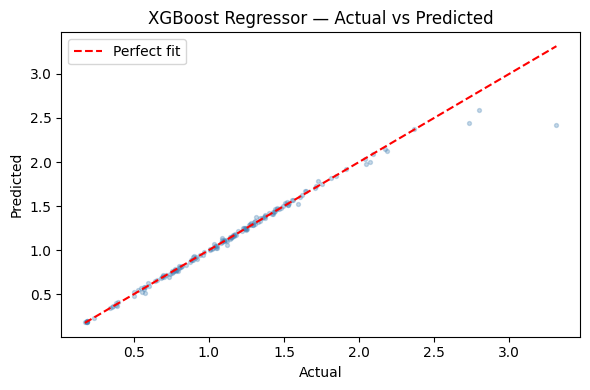

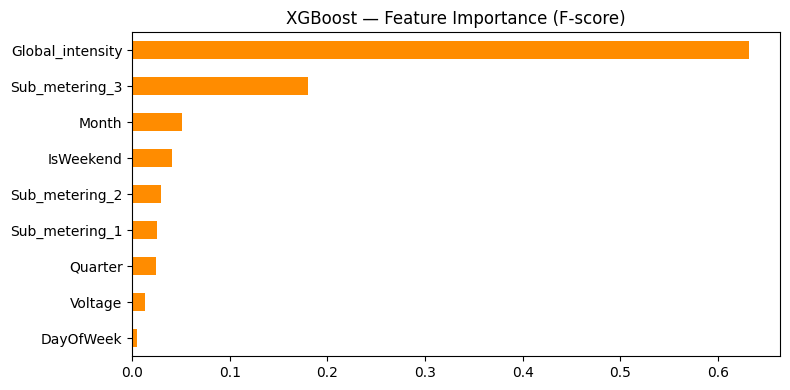

In [21]:
#  MODEL 8: XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_reg_model, xgb_reg_preds = eval_regression(
    'XGBoost Regressor', xgb_reg,
    X_train_r, y_train_r, X_test_r, y_test_r
)
plot_actual_vs_pred('XGBoost Regressor', y_test_r, xgb_reg_preds)

# Feature importance from XGBoost
fi_xgb = pd.Series(xgb_reg_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi_xgb.plot(kind='barh', figsize=(8,4), color='darkorange',
            title='XGBoost — Feature Importance (F-score)')
plt.tight_layout(); plt.show()

  SVR (RBF kernel)
  RMSE : 0.1326
  MAE  : 0.0710
  R²   : 0.9350


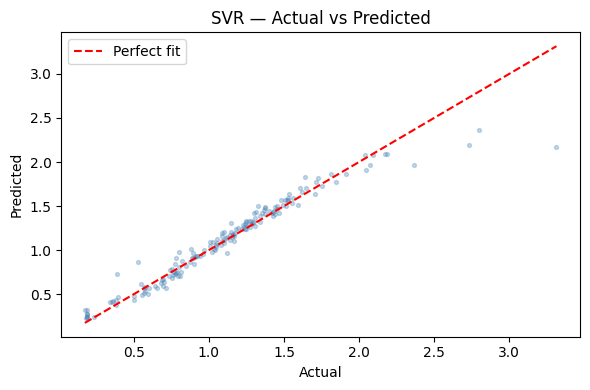

In [22]:
# — MODEL 9: Support Vector Regression (SVR)
# Uses scaled data — MANDATORY for SVR
svr_model, svr_preds = eval_regression(
    'SVR (RBF kernel)', SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    X_train_rs, y_train_r, X_test_rs, y_test_r
)
plot_actual_vs_pred('SVR', y_test_r, svr_preds)

Best k = 4


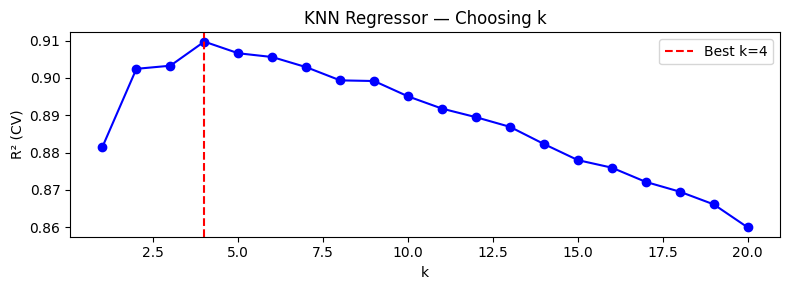

  KNN Regressor (k=4)
  RMSE : 0.1571
  MAE  : 0.0973
  R²   : 0.9088


In [23]:
#  MODEL 10: K-Nearest Neighbours Regressor
# Find best k first
k_scores = []
for k in range(1, 21):
    knn_tmp = KNeighborsRegressor(n_neighbors=k)
    scores  = cross_val_score(knn_tmp, X_train_rs, y_train_r, cv=5, scoring='r2')
    k_scores.append((k, scores.mean()))

k_df = pd.DataFrame(k_scores, columns=['k', 'R²'])
best_k = k_df.loc[k_df['R²'].idxmax(), 'k']
print(f"Best k = {best_k}")

plt.figure(figsize=(8, 3))
plt.plot(k_df['k'], k_df['R²'], 'bo-')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('R² (CV)'); plt.title('KNN Regressor — Choosing k')
plt.legend(); plt.tight_layout(); plt.show()

knn_reg_model, knn_reg_preds = eval_regression(
    f'KNN Regressor (k={best_k})', KNeighborsRegressor(n_neighbors=int(best_k)),
    X_train_rs, y_train_r, X_test_rs, y_test_r
)

  Logistic Regression
  Accuracy : 0.9699
  AUC-ROC  : 0.9987
              precision    recall  f1-score   support

   Low Usage       1.00      0.94      0.97        83
  High Usage       0.94      1.00      0.97        83

    accuracy                           0.97       166
   macro avg       0.97      0.97      0.97       166
weighted avg       0.97      0.97      0.97       166



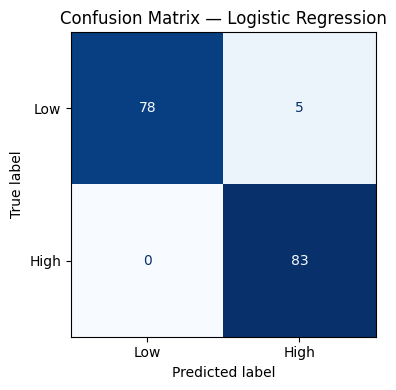

In [24]:
#  MODEL 11: Logistic Regression (Classification)
log_model, log_preds = eval_classification(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train_cs, y_train_c, X_test_cs, y_test_c
)
plot_confusion('Logistic Regression', y_test_c, log_preds)

  Decision Tree Classifier
  Accuracy : 0.9819
  AUC-ROC  : 0.9933
              precision    recall  f1-score   support

   Low Usage       0.98      0.99      0.98        83
  High Usage       0.99      0.98      0.98        83

    accuracy                           0.98       166
   macro avg       0.98      0.98      0.98       166
weighted avg       0.98      0.98      0.98       166

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}


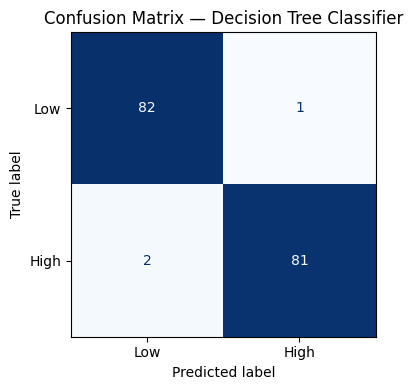

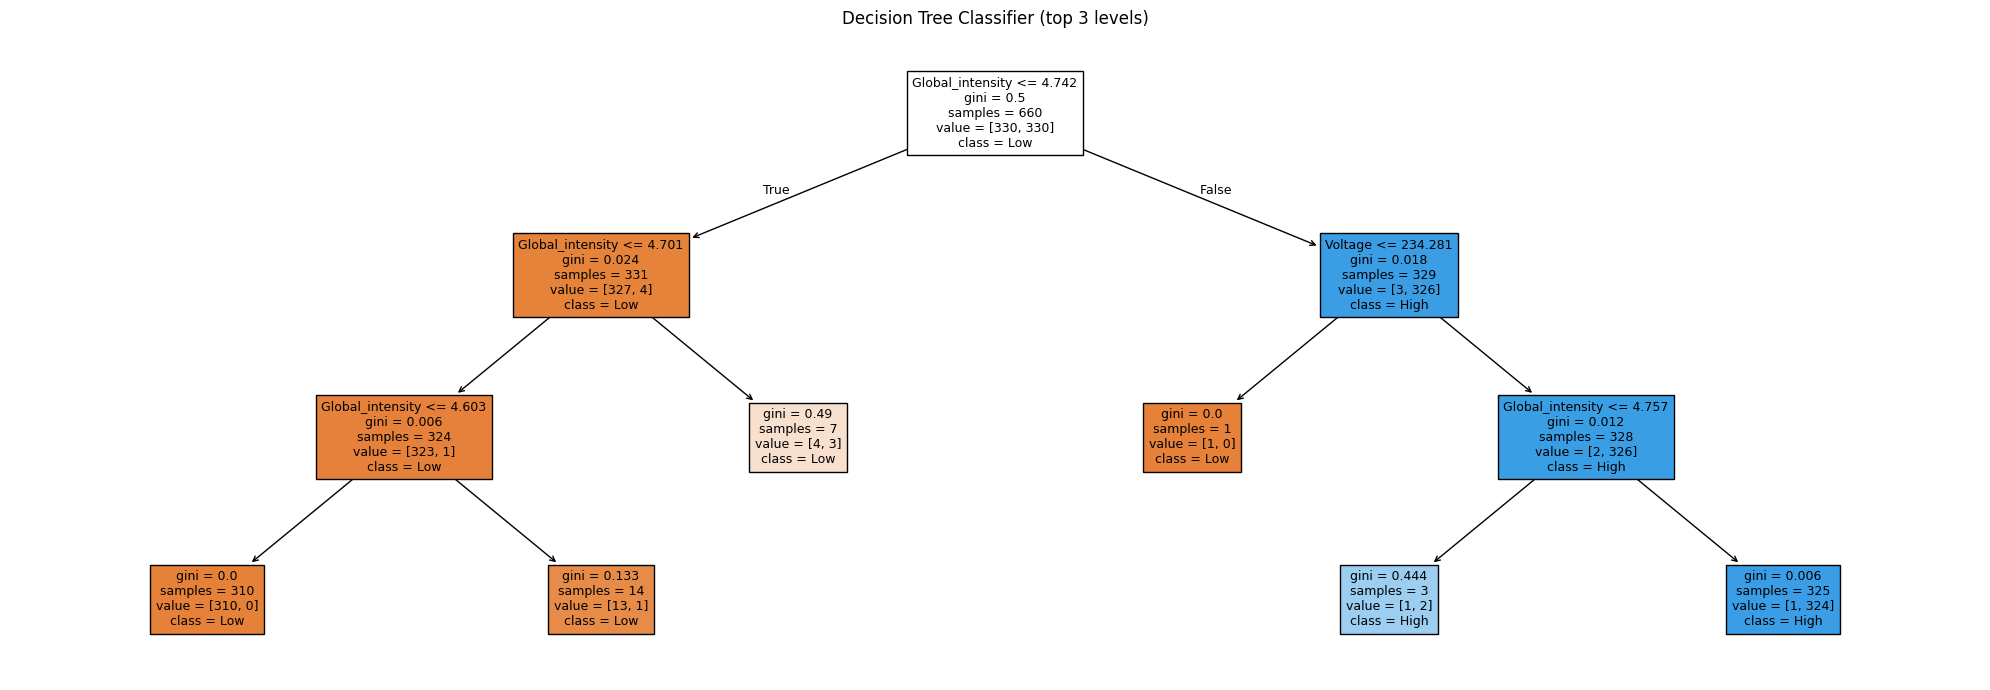

In [25]:
#  MODEL 12: Decision Tree Classifier
dt_clf_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth':        [3, 5, 7, 10],
        'min_samples_split':[2, 5, 10],
        'criterion':        ['gini', 'entropy']
    },
    cv=5, scoring='roc_auc', n_jobs=-1
)
dt_clf_model, dt_clf_preds = eval_classification(
    'Decision Tree Classifier', dt_clf_gs,
    X_train_c, y_train_c, X_test_c, y_test_c
)
print(f"Best params: {dt_clf_gs.best_params_}")
plot_confusion('Decision Tree Classifier', y_test_c, dt_clf_preds)

# Visualise tree
plt.figure(figsize=(20, 7))
plot_tree(dt_clf_gs.best_estimator_, max_depth=3,
          feature_names=FEATURES, class_names=['Low','High'],
          filled=True, fontsize=9)
plt.title('Decision Tree Classifier (top 3 levels)')
plt.tight_layout(); plt.show()

  Random Forest Classifier
  Accuracy : 0.9940
  AUC-ROC  : 0.9999
              precision    recall  f1-score   support

   Low Usage       0.99      1.00      0.99        83
  High Usage       1.00      0.99      0.99        83

    accuracy                           0.99       166
   macro avg       0.99      0.99      0.99       166
weighted avg       0.99      0.99      0.99       166



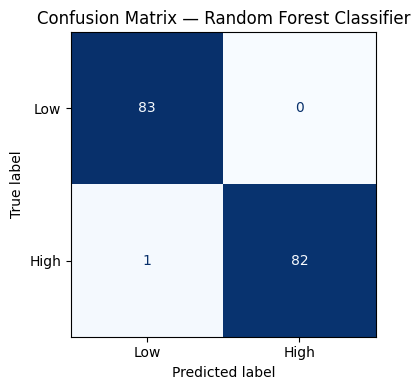

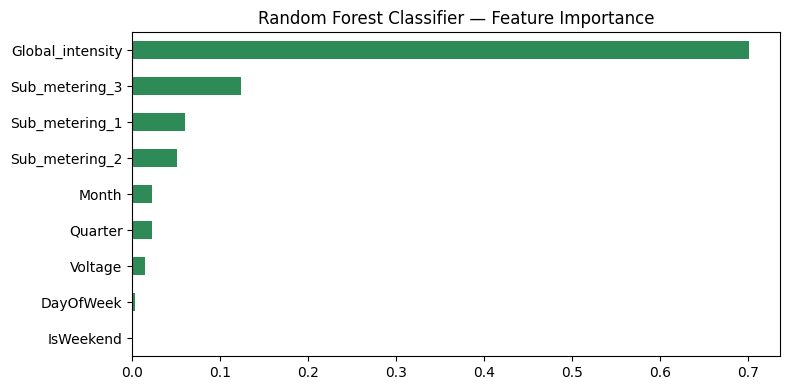

In [26]:
#  MODEL 13: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 random_state=42, n_jobs=-1)
rf_clf_model, rf_clf_preds = eval_classification(
    'Random Forest Classifier', rf_clf,
    X_train_c, y_train_c, X_test_c, y_test_c
)
plot_confusion('Random Forest Classifier', y_test_c, rf_clf_preds)

# Feature importance
fi_rf = pd.Series(rf_clf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi_rf.plot(kind='barh', figsize=(8,4), color='seagreen',
           title='Random Forest Classifier — Feature Importance')
plt.tight_layout(); plt.show()

  Gradient Boosting Classifier
  Accuracy : 0.9880
  AUC-ROC  : 0.9996
              precision    recall  f1-score   support

   Low Usage       0.98      1.00      0.99        83
  High Usage       1.00      0.98      0.99        83

    accuracy                           0.99       166
   macro avg       0.99      0.99      0.99       166
weighted avg       0.99      0.99      0.99       166



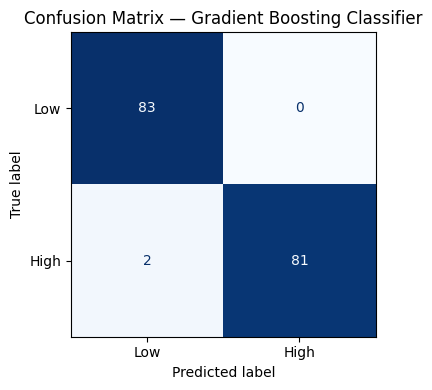

In [27]:
#  — MODEL 14: Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8,
    random_state=42
)
gb_clf_model, gb_clf_preds = eval_classification(
    'Gradient Boosting Classifier', gb_clf,
    X_train_c, y_train_c, X_test_c, y_test_c
)
plot_confusion('Gradient Boosting Classifier', y_test_c, gb_clf_preds)

  XGBoost Classifier
  Accuracy : 0.9940
  AUC-ROC  : 1.0000
              precision    recall  f1-score   support

   Low Usage       0.99      1.00      0.99        83
  High Usage       1.00      0.99      0.99        83

    accuracy                           0.99       166
   macro avg       0.99      0.99      0.99       166
weighted avg       0.99      0.99      0.99       166



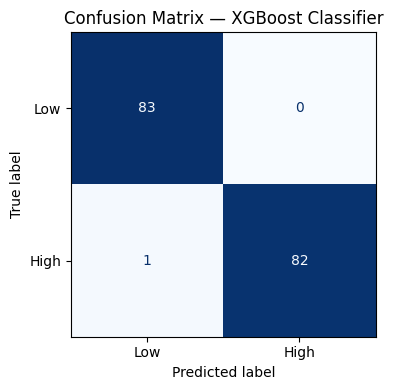

In [28]:
# — MODEL 15: XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_clf_model, xgb_clf_preds = eval_classification(
    'XGBoost Classifier', xgb_clf,
    X_train_c, y_train_c, X_test_c, y_test_c
)
plot_confusion('XGBoost Classifier', y_test_c, xgb_clf_preds)

  SVM Classifier (RBF)
  Accuracy : 0.9518
  AUC-ROC  : 0.9936
              precision    recall  f1-score   support

   Low Usage       0.94      0.96      0.95        83
  High Usage       0.96      0.94      0.95        83

    accuracy                           0.95       166
   macro avg       0.95      0.95      0.95       166
weighted avg       0.95      0.95      0.95       166



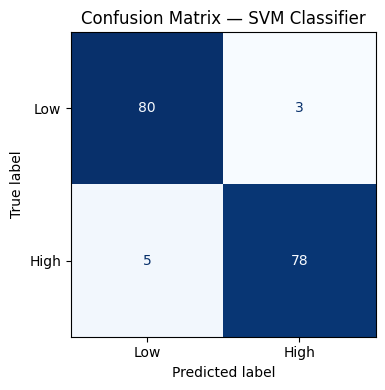

In [29]:
#  MODEL 16: SVM Classifier (RBF kernel)
# Uses scaled data
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_clf_model, svm_clf_preds = eval_classification(
    'SVM Classifier (RBF)', svm_clf,
    X_train_cs, y_train_c, X_test_cs, y_test_c
)
plot_confusion('SVM Classifier', y_test_c, svm_clf_preds)

Best k = 20


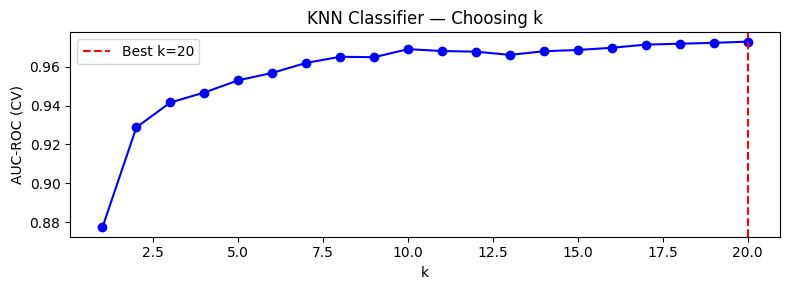

  KNN Classifier (k=20)
  Accuracy : 0.8614
  AUC-ROC  : 0.9668
              precision    recall  f1-score   support

   Low Usage       0.81      0.94      0.87        83
  High Usage       0.93      0.78      0.85        83

    accuracy                           0.86       166
   macro avg       0.87      0.86      0.86       166
weighted avg       0.87      0.86      0.86       166



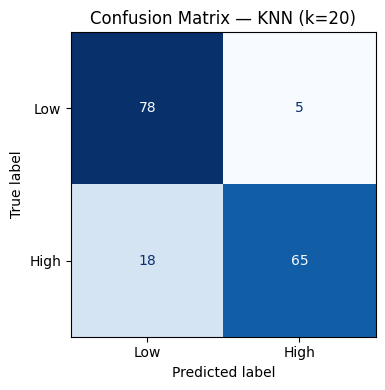

In [30]:
#  MODEL 17: K-Nearest Neighbours Classifier
# Find best k
k_acc = []
for k in range(1, 21):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores  = cross_val_score(knn_tmp, X_train_cs, y_train_c, cv=5, scoring='roc_auc')
    k_acc.append((k, scores.mean()))

k_df2   = pd.DataFrame(k_acc, columns=['k', 'AUC'])
best_k2 = k_df2.loc[k_df2['AUC'].idxmax(), 'k']
print(f"Best k = {best_k2}")

plt.figure(figsize=(8, 3))
plt.plot(k_df2['k'], k_df2['AUC'], 'bo-')
plt.axvline(best_k2, color='red', linestyle='--', label=f'Best k={best_k2}')
plt.xlabel('k'); plt.ylabel('AUC-ROC (CV)'); plt.title('KNN Classifier — Choosing k')
plt.legend(); plt.tight_layout(); plt.show()

knn_clf_model, knn_clf_preds = eval_classification(
    f'KNN Classifier (k={best_k2})', KNeighborsClassifier(n_neighbors=int(best_k2)),
    X_train_cs, y_train_c, X_test_cs, y_test_c
)
plot_confusion(f'KNN (k={best_k2})', y_test_c, knn_clf_preds)

  Gaussian Naive Bayes
  Accuracy : 0.8916
  AUC-ROC  : 0.9610
              precision    recall  f1-score   support

   Low Usage       0.87      0.92      0.89        83
  High Usage       0.91      0.87      0.89        83

    accuracy                           0.89       166
   macro avg       0.89      0.89      0.89       166
weighted avg       0.89      0.89      0.89       166



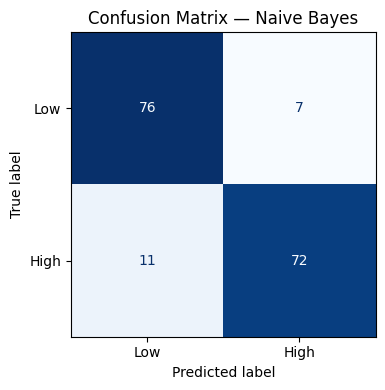

In [31]:
#  MODEL 18: Gaussian Naive Bayes
nb_model, nb_preds = eval_classification(
    'Gaussian Naive Bayes', GaussianNB(),
    X_train_cs, y_train_c, X_test_cs, y_test_c
)
plot_confusion('Naive Bayes', y_test_c, nb_preds)

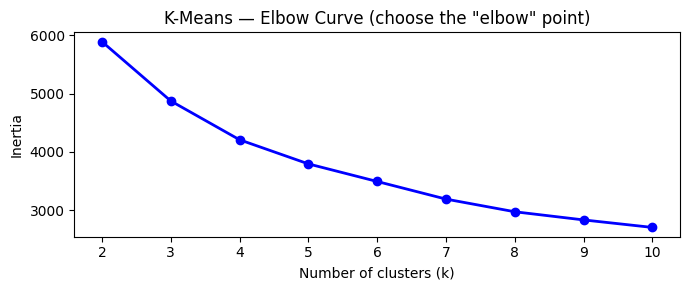

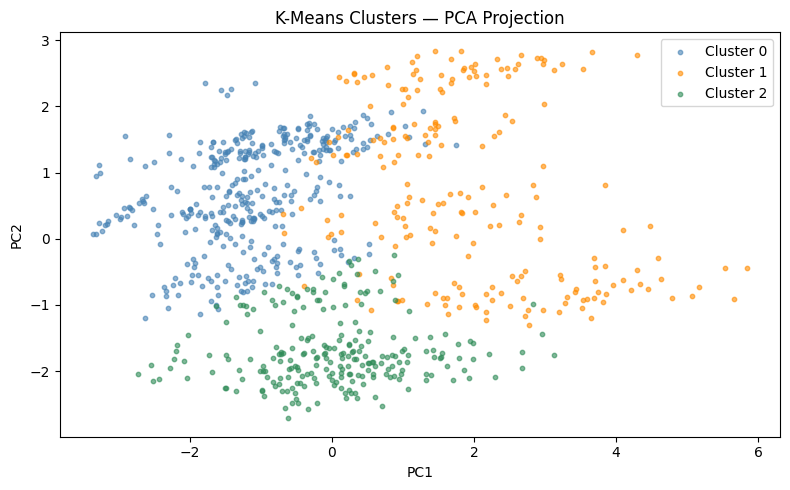

Cluster profiles (avg active power):
         Global_active_power  Bill_INR  Month
Cluster                                      
0                      0.909   141.758  8.544
1                      1.438   224.306  6.213
2                      1.199   186.984  2.477


In [32]:
#  MODEL 19: K-Means Clustering (Unsupervised)
X_all_scaled = StandardScaler().fit_transform(daily[FEATURES])

# Elbow method to choose k
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 3))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2)
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia')
plt.title('K-Means — Elbow Curve (choose the "elbow" point)')
plt.tight_layout(); plt.show()

# Fit with k=3
kmeans    = KMeans(n_clusters=3, random_state=42, n_init=10)
daily['Cluster'] = kmeans.fit_predict(X_all_scaled)

# PCA for 2D visualisation
pca     = PCA(n_components=2)
X_pca   = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for cl in range(3):
    mask = daily['Cluster'] == cl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cl], label=f'Cluster {cl}', s=10, alpha=0.6)
plt.title('K-Means Clusters — PCA Projection')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()

# Cluster profiles
print("Cluster profiles (avg active power):")
print(daily.groupby('Cluster')[['Global_active_power','Bill_INR','Month']].mean().round(3))

DBSCAN found 1 clusters and 821 anomalous days


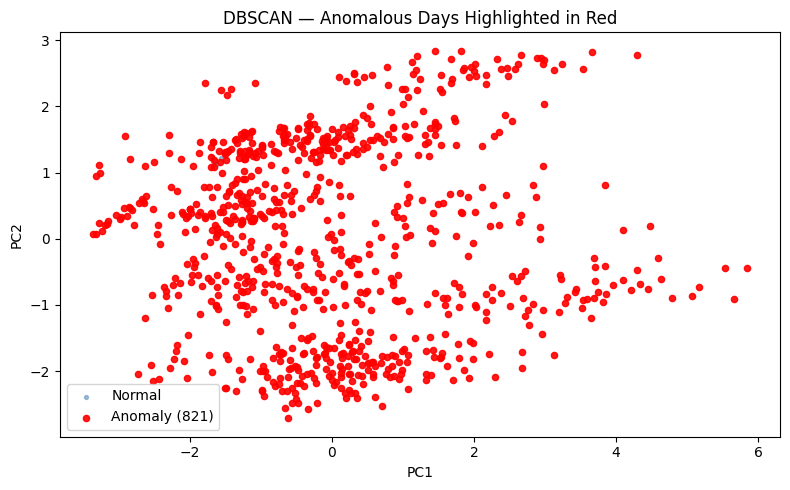


Anomalous days detected:
            Global_active_power    Bill_INR  Month
Datetime                                          
2006-12-16             3.053475  476.342061     12
2006-12-17             2.354486  367.299833     12
2006-12-18             1.530435  238.747817     12
2006-12-19             1.157079  180.504350     12
2006-12-20             1.545658  241.122700     12
2006-12-21             1.193758  186.226248     12
2006-12-22             1.625929  253.644950     12
2006-12-23             3.314851  517.116817     12
2006-12-24             1.770842  276.251300     12
2006-12-25             1.904944  297.171333     12


In [33]:
#  MODEL 20: DBSCAN — Density-Based Anomaly Detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
daily['DBSCAN_label'] = dbscan.fit_predict(X_all_scaled)

n_clusters = len(set(daily['DBSCAN_label'])) - (1 if -1 in daily['DBSCAN_label'].values else 0)
n_noise    = (daily['DBSCAN_label'] == -1).sum()
print(f"DBSCAN found {n_clusters} clusters and {n_noise} anomalous days")

# Visualise anomalies in PCA space
plt.figure(figsize=(8, 5))
normal  = daily['DBSCAN_label'] != -1
anomaly = daily['DBSCAN_label'] == -1
plt.scatter(X_pca[normal,  0], X_pca[normal,  1], c='steelblue', s=8,  alpha=0.5, label='Normal')
plt.scatter(X_pca[anomaly, 0], X_pca[anomaly, 1], c='red',       s=20, alpha=0.9, label=f'Anomaly ({n_noise})')
plt.title('DBSCAN — Anomalous Days Highlighted in Red')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()

# Show the anomalous dates
print("\nAnomalous days detected:")
print(daily[anomaly][['Global_active_power','Bill_INR','Month']].head(10))

  MLP Neural Network (Regressor)
  RMSE : 0.0344
  MAE  : 0.0216
  R²   : 0.9956


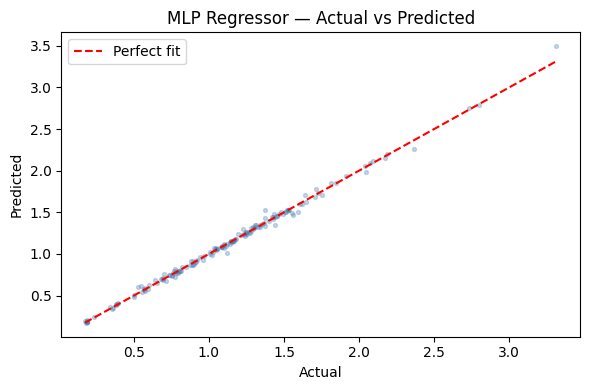

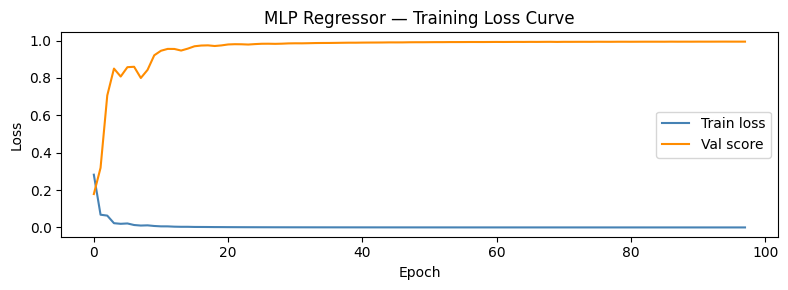

In [34]:
# MODEL 21a: MLP Neural Network — Regression
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_reg_model, mlp_reg_preds = eval_regression(
    'MLP Neural Network (Regressor)', mlp_reg,
    X_train_rs, y_train_r, X_test_rs, y_test_r
)
plot_actual_vs_pred('MLP Regressor', y_test_r, mlp_reg_preds)

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(mlp_reg_model.loss_curve_, color='steelblue', label='Train loss')
if hasattr(mlp_reg_model, 'validation_scores_'):
    plt.plot(mlp_reg_model.validation_scores_, color='darkorange', label='Val score')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('MLP Regressor — Training Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()

  MLP Neural Network (Classifier)
  Accuracy : 0.9096
  AUC-ROC  : 0.9636
              precision    recall  f1-score   support

   Low Usage       0.90      0.92      0.91        83
  High Usage       0.91      0.90      0.91        83

    accuracy                           0.91       166
   macro avg       0.91      0.91      0.91       166
weighted avg       0.91      0.91      0.91       166



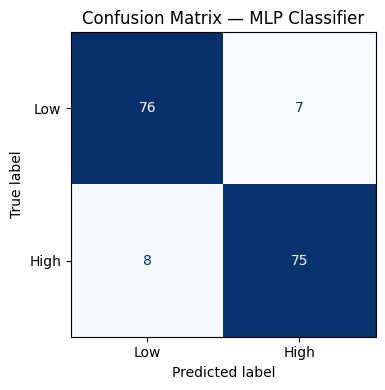

In [35]:
# — MODEL 21b: MLP Neural Network — Classification
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_clf_model, mlp_clf_preds = eval_classification(
    'MLP Neural Network (Classifier)', mlp_clf,
    X_train_cs, y_train_c, X_test_cs, y_test_c
)
plot_confusion('MLP Classifier', y_test_c, mlp_clf_preds)

Training months: 22  |  Test months: 6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:               Bill_INR   No. Observations:                   22
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -179.995
Date:                Mon, 25 May 2026   AIC                            369.990
Time:                        09:05:48   BIC                            375.212
Sample:                    12-31-2006   HQIC                           371.123
                         - 09-30-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5919      0.078     20.422      0.000       1.439       1.745
ar.L2         -0.8792      0.158     -5.581      0.000      -1.188      -0.570
ma.L1         -1.8353      0.332     -5.536      0.0

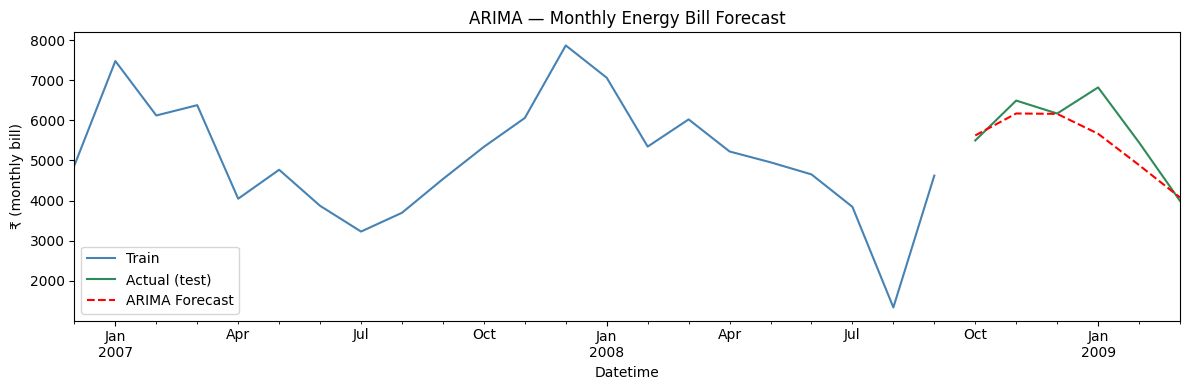

In [36]:
#  — MODEL 22: ARIMA — Monthly Energy Bill Forecast
# Aggregate to monthly level
monthly_bill = daily['Bill_INR'].resample('M').sum().dropna()

# Train on all but last 6 months
train_ts = monthly_bill.iloc[:-6]
test_ts  = monthly_bill.iloc[-6:]

print(f"Training months: {len(train_ts)}  |  Test months: {len(test_ts)}")

# Fit ARIMA(2,1,2)
arima_model = ARIMA(train_ts, order=(2, 1, 2))
arima_fit   = arima_model.fit()
print(arima_fit.summary())

# Forecast
forecast_arima = arima_fit.forecast(steps=6)

rmse_arima = np.sqrt(mean_squared_error(test_ts.values, forecast_arima.values))
print(f"\nARIMA RMSE on held-out 6 months: ₹{rmse_arima:.2f}")

# Plot
plt.figure(figsize=(12, 4))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual (test)', color='seagreen', linewidth=1.5)
pd.Series(forecast_arima.values, index=test_ts.index).plot(
    label='ARIMA Forecast', color='red', linestyle='--', linewidth=1.5)
plt.title('ARIMA — Monthly Energy Bill Forecast')
plt.ylabel('₹ (monthly bill)'); plt.legend()
plt.tight_layout(); plt.show()

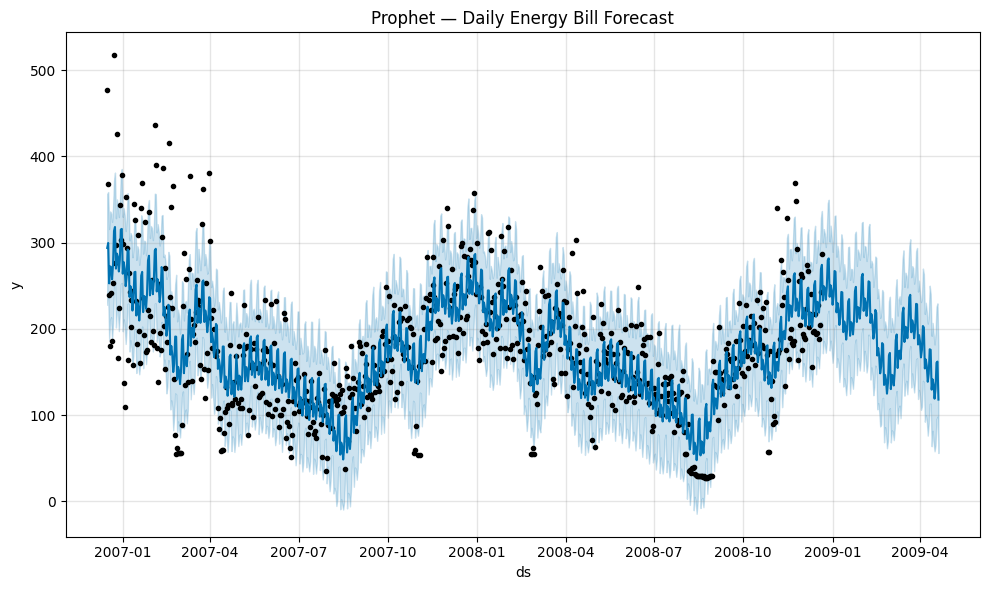

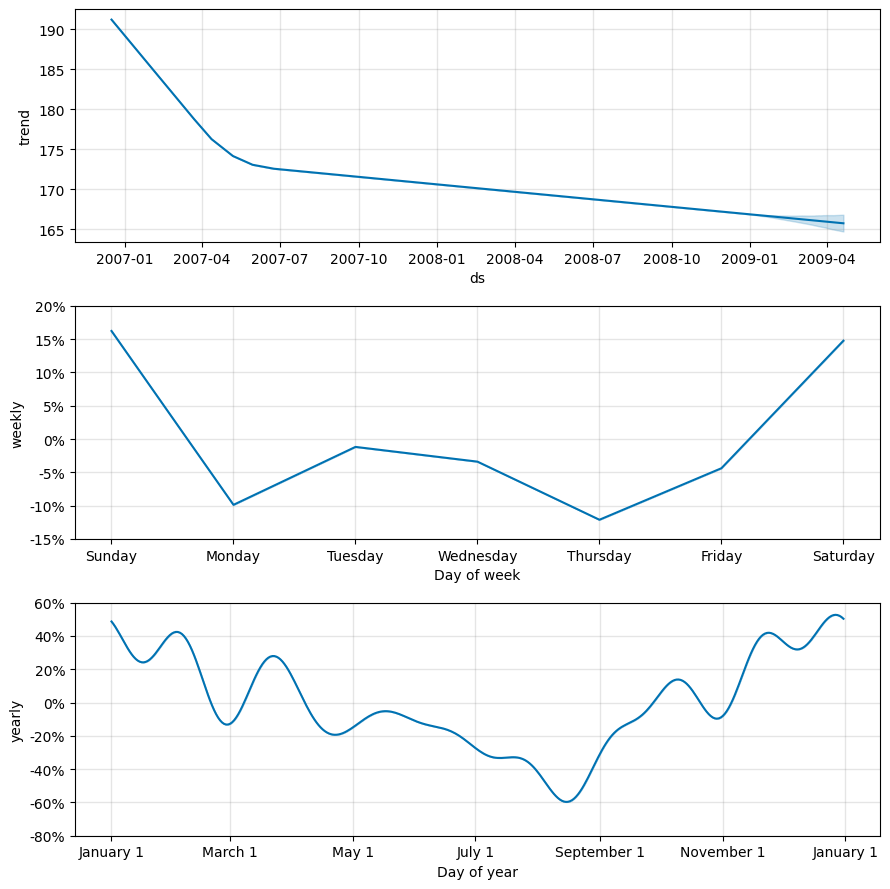

Prophet RMSE on last 90 days: ₹61.16


In [37]:
#  — MODEL 23: Prophet — Trend + Seasonality Forecast
# Prophet expects columns named 'ds' and 'y'
prophet_df = daily[['Bill_INR']].reset_index().rename(
    columns={'Datetime': 'ds', 'Bill_INR': 'y'}
)

train_p = prophet_df.iloc[:-90]   # hold out last 90 days
test_p  = prophet_df.iloc[-90:]

m = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m.fit(train_p)

# Predict 120 days into the future
future   = m.make_future_dataframe(periods=120)
forecast = m.predict(future)

# Forecast plot
fig1 = m.plot(forecast)
plt.title('Prophet — Daily Energy Bill Forecast')
plt.tight_layout(); plt.show()

# Components: trend + weekly + yearly
fig2 = m.plot_components(forecast)
plt.tight_layout(); plt.show()

# RMSE on held-out 90 days
pred_p = forecast.set_index('ds').reindex(test_p['ds'].values)['yhat']
rmse_p = np.sqrt(mean_squared_error(test_p['y'].values, pred_p.values))
print(f"Prophet RMSE on last 90 days: ₹{rmse_p:.2f}")

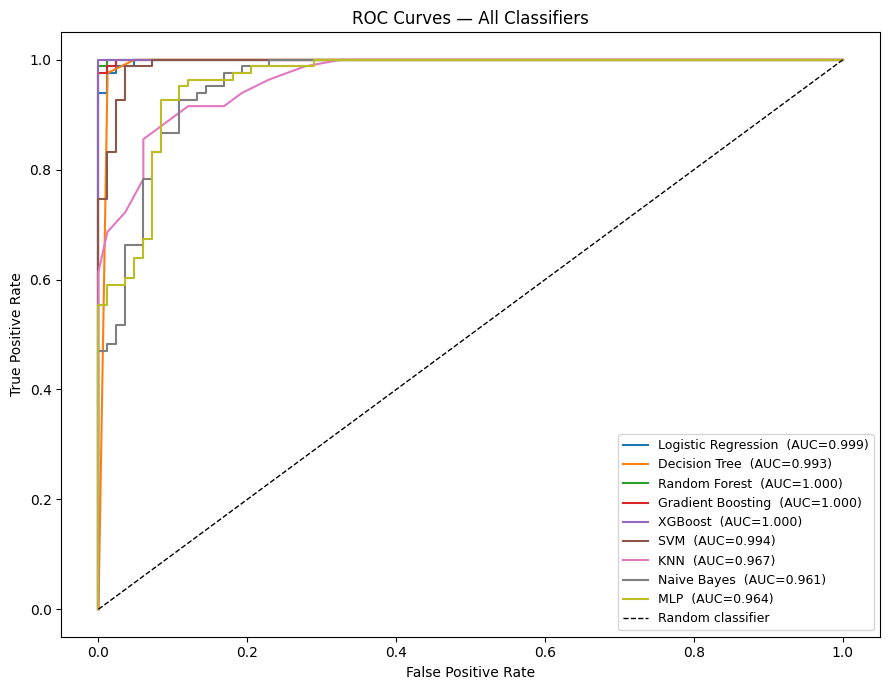

In [38]:
#  — ROC Curves for All Classifiers
clf_roc_models = {
    'Logistic Regression': (log_model,     X_test_cs),
    'Decision Tree':        (dt_clf_gs,     X_test_c),
    'Random Forest':        (rf_clf_model,  X_test_c),
    'Gradient Boosting':    (gb_clf_model,  X_test_c),
    'XGBoost':              (xgb_clf_model, X_test_c),
    'SVM':                  (svm_clf_model, X_test_cs),
    'KNN':                  (knn_clf_model, X_test_cs),
    'Naive Bayes':          (nb_model,      X_test_cs),
    'MLP':                  (mlp_clf_model, X_test_cs),
}

plt.figure(figsize=(9, 7))
for name, (model, X_te) in clf_roc_models.items():
    try:
        proba = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        proba = model.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc = roc_auc_score(y_test_c, proba)
    plt.plot(fpr, tpr, linewidth=1.5, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classifiers')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


  REGRESSION LEADERBOARD  (higher R² = better)
                             Model    RMSE     MAE      R²
1    Polynomial Regression (deg 2)  0.0104  0.0077  0.9996
2                 Ridge Regression  0.0118  0.0088  0.9995
3                Linear Regression  0.0118  0.0088  0.9995
4                 Lasso Regression  0.0117  0.0088  0.9995
5   MLP Neural Network (Regressor)  0.0344  0.0216  0.9956
6      Gradient Boosting Regressor  0.0406  0.0119  0.9939
7          Decision Tree Regressor  0.0411  0.0164  0.9937
8          Random Forest Regressor  0.0550  0.0170  0.9888
9                XGBoost Regressor  0.0774  0.0219  0.9779
10                SVR (RBF kernel)  0.1326  0.0710  0.9350
11             KNN Regressor (k=4)  0.1571  0.0973  0.9088

  CLASSIFICATION LEADERBOARD  (higher AUC-ROC = better)
                             Model  Accuracy  AUC-ROC
1               XGBoost Classifier    0.9940   1.0000
2         Random Forest Classifier    0.9940   0.9999
3     Gradient Boosting C

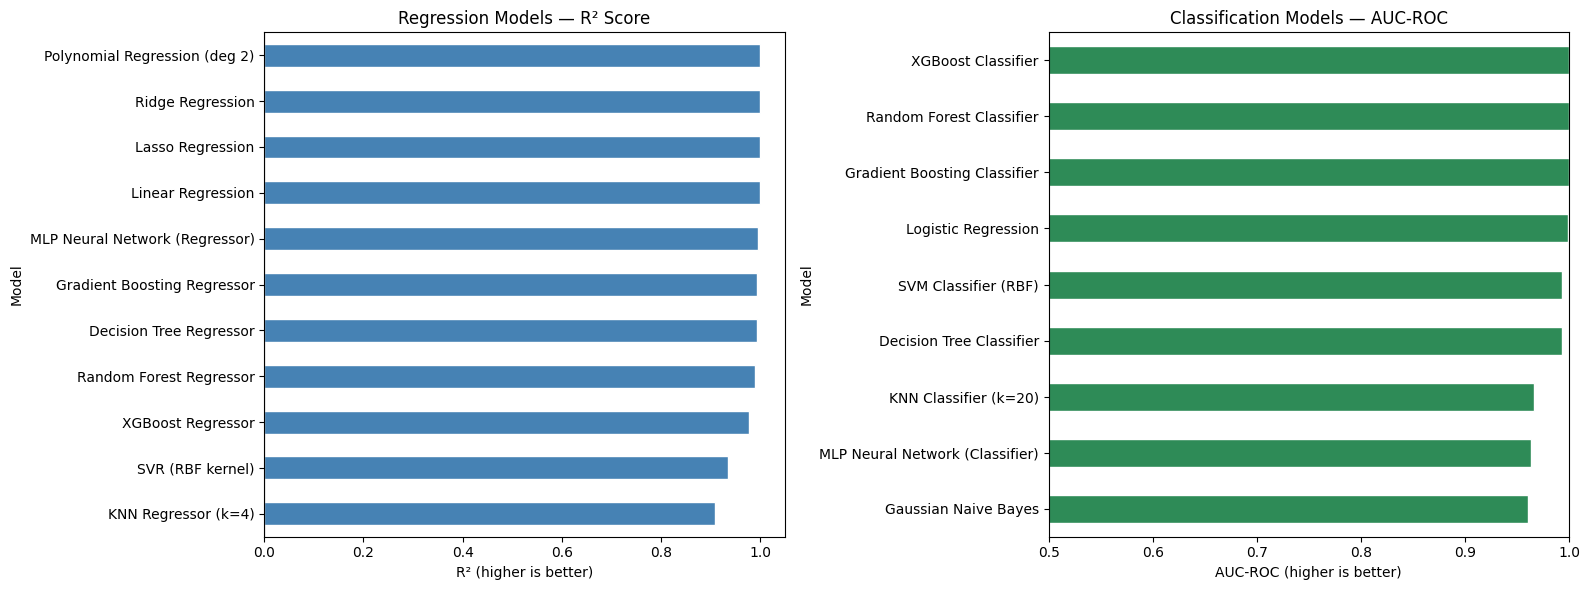

In [39]:
# — Final Leaderboard
print("\n" + "="*60)
print("  REGRESSION LEADERBOARD  (higher R² = better)")
print("="*60)
reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
reg_df.index += 1
print(reg_df.to_string())

print("\n" + "="*60)
print("  CLASSIFICATION LEADERBOARD  (higher AUC-ROC = better)")
print("="*60)
clf_df = pd.DataFrame(clf_results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
clf_df.index += 1
print(clf_df.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

reg_df.sort_values('R²').plot(
    kind='barh', x='Model', y='R²', ax=axes[0],
    color='steelblue', legend=False, edgecolor='white')
axes[0].set_title('Regression Models — R² Score')
axes[0].set_xlabel('R² (higher is better)')
axes[0].axvline(0, color='black', linewidth=0.8)

clf_df.sort_values('AUC-ROC').plot(
    kind='barh', x='Model', y='AUC-ROC', ax=axes[1],
    color='seagreen', legend=False, edgecolor='white')
axes[1].set_title('Classification Models — AUC-ROC')
axes[1].set_xlabel('AUC-ROC (higher is better)')
axes[1].set_xlim(0.5, 1.0)

plt.tight_layout(); plt.show()